# Imager Validation: NOAA-20 VIIRS

This notebook validates TAT-C's representation of horizontal imagers against the [Visible Infrared Imaging Radiometer Suite (VIIRS)](https://www.star.nesdis.noaa.gov/jpss/VIIRS.php) aboard NOAA-20 (JPSS-1). VIIRS is a 22-band visible and infrared radiometer with a rotating telescope that scans perpendicular to the flight direction every 1.79 s, within 56.28 deg of nadir (a swath about 3,040 km wide). Each scan images 16 rows of moderate-resolution (M-band) detectors at once, about 750 m apart at nadir, so a scan covers a strip about 12 km long along track: about the distance NOAA-20's ground track advances in one scan period. Across track, the samples of each row are aggregated on board into 3,200 pixels, in three zones that keep the pixel size more uniform across the scan.

As described in the companion notebook, [Imager Validation: NOAA-20 ATMS](ValidateImagerATMS.ipynb), TAT-C represents a nadir-pointing imager as an `Instrument` with a field of regard or a `PointedInstrument` with cross-track and along-track fields of view, and does not model the scan mechanism: the along-track field of view stands in for the time the instrument takes to sweep the ground. VIIRS is a natural test of this convention, since its 16-detector array is designed to cover the ground traveled in one scan. The ATMS notebook found that NOAA-20 scans perpendicular to its *inertial* velocity and that `PointedInstrument.velocity_frame=VelocityFrame.INERTIAL` reproduces this. This notebook asks five questions:

1. **Orbit.** Does TAT-C's propagation of the operational two-line element (TLE) set reproduce NOAA-20's position?
2. **Scan geometry.** What are VIIRS's scan angles and the angular extent of its detector array, and is its scan perpendicular to the inertial velocity like that of ATMS?
3. **Scan footprint.** Does a rectangular `PointedInstrument` view, tailored to one scan period, reproduce the ground footprint of a VIIRS scan, including its growth toward the swath edges (the "bow tie" effect)?
4. **Swath width.** Does the field of regard reproduce the VIIRS swath width?
5. **Daily observations.** Does `collect_observations` predict which points VIIRS observes in a day, when, and at what elevation angle?

## Reference Data

The NOAA-20 archive on AWS ([`noaa-nesdis-n20-pds`](https://registry.opendata.aws/noaa-jpss/)) is public and requires no account. Two products are used:

* **VIIRS terrain-corrected moderate-resolution geolocation** (`VIIRS-MOD-GEO-TC`, files `GMTCO_*`): one HDF5 file per granule of 48 scans (about 86 s). For each scan, it gives the start and middle times and the spacecraft's Earth-fixed position and velocity at the middle time; for each of the 768 x 3,200 pixels (48 scans of 16 detectors), the geodetic latitude, longitude, and terrain height; and, for the granule, a *G-ring*: the vertices of a polygon outlining the granule.
* **Two-line elements** (`TLE-AUX`): the element sets used by the JPSS ground system, one per day with an epoch at 00:00 UTC.

One day (2 October 2026) has 1,013 granules totaling about 27 GB, so only parts of the files are downloaded, with HTTP range requests (read with `h5py`, `pip install h5py`): the scan metadata and G-ring of every granule, which sit at the start and end of each file (about 0.8 MB each), and the pixel latitudes, longitudes, and heights (about 7 MB) of every tenth granule. The first run transfers about 1.5 GB and takes several minutes; reduced arrays are cached in a local `data/jpss` directory, so later runs are fast.

In [1]:
import concurrent.futures
import io
import re
from datetime import datetime, timezone
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import requests

DATA_DIR = Path("data") / "jpss"
DATA_DIR.mkdir(parents=True, exist_ok=True)
BUCKET = "https://noaa-nesdis-n20-pds.s3.amazonaws.com/"
DAY = datetime(2026, 10, 2, tzinfo=timezone.utc)


def list_keys(prefix):
    """Keys of all objects in the bucket with a prefix."""
    keys, token = [], None
    while True:
        params = {"list-type": "2", "prefix": prefix}
        if token:
            params["continuation-token"] = token
        listing = requests.get(BUCKET, params=params, timeout=60).text
        keys += re.findall(r"<Key>(.*?)</Key>", listing)
        match = re.search(r"<NextContinuationToken>(.*?)</NextContinuationToken>", listing)
        if match is None:
            return keys
        token = match.group(1)


def fetch(key):
    """Download an object, retrying transient failures."""
    for attempt in range(5):
        try:
            response = requests.get(BUCKET + key, timeout=120)
            response.raise_for_status()
            return response.content
        except requests.RequestException:
            if attempt == 4:
                raise


class RemoteFile(io.RawIOBase):
    """Read-only file object that downloads blocks of a remote object with HTTP range requests on demand."""

    def __init__(self, key, block_size=2**16):
        self.url, self.block_size, self.blocks, self.position = BUCKET + key, block_size, {}, 0
        self.session = requests.Session()
        self.size = int(self.session.head(self.url, timeout=60).headers["Content-Length"])

    def readable(self):
        return True

    def seekable(self):
        return True

    def tell(self):
        return self.position

    def seek(self, offset, whence=io.SEEK_SET):
        self.position = {io.SEEK_SET: 0, io.SEEK_CUR: self.position, io.SEEK_END: self.size}[whence] + offset
        return self.position

    def fetch(self, start, end):
        """Download (block-aligned) bytes [start, end) into the cache."""
        for attempt in range(5):
            try:
                response = self.session.get(self.url, headers={"Range": f"bytes={start}-{end - 1}"}, timeout=120)
                response.raise_for_status()
                break
            except requests.RequestException:
                if attempt == 4:
                    raise
        for i, block in enumerate(range(start // self.block_size, (end - 1) // self.block_size + 1)):
            self.blocks[block] = response.content[i * self.block_size : (i + 1) * self.block_size]

    def readinto(self, buffer):
        n = min(len(buffer), self.size - self.position)
        if n <= 0:
            return 0
        first, last = self.position // self.block_size, (self.position + n - 1) // self.block_size
        missing = [block for block in range(first, last + 1) if block not in self.blocks]
        if missing:
            self.fetch(missing[0] * self.block_size, min((missing[-1] + 1) * self.block_size, self.size))
        data = b"".join(self.blocks[block] for block in range(first, last + 1))
        start = self.position - first * self.block_size
        buffer[:n] = data[start : start + n]
        self.position += n
        return n


def open_granule(key):
    """Open a remote granule, prefetching the metadata at the start and end of the file."""
    remote = RemoteFile(key)
    remote.fetch(0, remote.block_size)
    remote.fetch((remote.size - 2**19) // remote.block_size * remote.block_size, remote.size)
    return h5py.File(remote)


TLE_FILE = DATA_DIR / f"n20_tle_{DAY:%Y%m%d}.txt"
if not TLE_FILE.exists():
    # the element set with an epoch at the start of the day
    key = next(k for k in list_keys(f"TLE-AUX/{DAY:%Y/%m/%d}/") if f"Z_{DAY:%Y%m%d}000000Z_" in k)
    with h5py.File(io.BytesIO(fetch(key))) as f:
        TLE_FILE.write_text(bytes(f["All_Data/TLE-AUX_All/Dataset_Array_0"][:]).decode().strip() + "\n")
tle = TLE_FILE.read_text().splitlines()

GEO = "All_Data/VIIRS-MOD-GEO-TC_All/"
GRAN = "Data_Products/VIIRS-MOD-GEO-TC/VIIRS-MOD-GEO-TC_Gran_0"
SCANS_FILE = DATA_DIR / f"viirs_gmtco_scans_{DAY:%Y%m%d}.npz"
PIXELS_FILE = DATA_DIR / f"viirs_gmtco_pixels_{DAY:%Y%m%d}.npz"
N_SCANS, N_DETECTORS, N_SAMPLES = 48, 16, 3200
PIXEL_GRANULES = 10  # every tenth granule
COLUMNS = np.unique(np.r_[np.arange(0, N_SAMPLES, 8), N_SAMPLES - 1])  # subsampled columns
ROWS = np.array([0, 7, 8, 15])  # detectors kept for every scan

if not (SCANS_FILE.exists() and PIXELS_FILE.exists()):
    keys = list_keys(f"VIIRS-MOD-GEO-TC/{DAY:%Y/%m/%d}/")

    def read_scans(key):
        with open_granule(key) as f:
            granule = f[GRAN]
            return {
                "gring_lat": granule.attrs["G-Ring_Latitude"].ravel(),
                "gring_lon": granule.attrs["G-Ring_Longitude"].ravel(),
                "n_scans": int(granule.attrs["N_Number_Of_Scans"].ravel()[0]),
                **{field: f[GEO + field][:] for field in ["StartTime", "MidTime", "SCPosition", "SCVelocity"]},
            }

    def read_pixels(key):
        with open_granule(key) as f:
            lat, lon, height = (f[GEO + field][:].reshape(N_SCANS, N_DETECTORS, N_SAMPLES) for field in ["Latitude", "Longitude", "Height"])
        center = N_SCANS // 2
        return {
            # selected detectors of every scan, at subsampled columns
            "lat": lat[:, ROWS][..., COLUMNS],
            "lon": lon[:, ROWS][..., COLUMNS],
            "height": height[:, ROWS][..., COLUMNS],
            # all samples of the two center detectors of the middle scan
            "lat_full": lat[center, 7:9],
            "lon_full": lon[center, 7:9],
            "height_full": height[center, 7:9],
        }

    with concurrent.futures.ThreadPoolExecutor(16) as pool:
        scans = list(pool.map(read_scans, keys))
        pixels = list(pool.map(read_pixels, keys[::PIXEL_GRANULES]))
    np.savez_compressed(SCANS_FILE, keys=np.array(keys), **{field: np.stack([s[field] for s in scans]) for field in scans[0]})
    np.savez_compressed(
        PIXELS_FILE,
        granule=np.arange(len(keys))[::PIXEL_GRANULES],
        **{field: np.stack([p[field] for p in pixels]) for field in pixels[0]},
    )

viirs = dict(np.load(SCANS_FILE))
viirs_pixels = dict(np.load(PIXELS_FILE))
print(tle[0], tle[1], sep="\n")
pd.Series(
    {
        "granules": len(viirs["keys"]),
        "scans": int(viirs["n_scans"].sum()),
        "granules with pixels": len(viirs_pixels["granule"]),
    }
)

1 43013U 17073A   26275.00000000  .00000083  00000-0  39562-4 0  2455
2 43013 098.7849 213.5412 0000651 045.7112 319.4843 14.19528658459636


granules                 1013
scans                   48393
granules with pixels      102
dtype: int64

## Setup

Times are converted from IDPS Epoch Time (microseconds since 1 January 1958 including leap seconds) to UTC as in the ATMS notebook, and scans beyond each granule's reported number of scans (fill values) are excluded.

TAT-C's nominal VIIRS model has a field of regard of 2 x 56.28 = 112.56 deg. Helper functions match those of the ATMS notebook; `view_tangents` computes the along-track and cross-track view angle tangents of a line of sight in TAT-C's instrument frame (as `tatc.utils.compute_view_tangents` does for a TAT-C orbit track), but from the reported spacecraft position and inertial velocity.

In [2]:
from datetime import timedelta

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from pyproj import Geod, Transformer
from skyfield.api import wgs84
from skyfield.framelib import itrs

from tatc.analysis import collect_observations
from tatc.constants import EARTH_MEAN_RADIUS, EARTH_ROTATION_RATE
from tatc.generation import generate_points_fibonacci_lattice
from tatc.schemas import GeneralPerturbationsOrbit, Instrument, Point, PointedInstrument, Satellite
from tatc.utils import (
    VelocityFrame,
    compute_apoapsis_radius,
    compute_field_of_regard,
    compute_min_elevation_angle,
    compute_projected_ray_position,
    field_of_regard_to_swath_width,
)

IET_EPOCH = pd.Timestamp("1958-01-01", tz="UTC")
LEAP_SECONDS = 37
EDGE = 56.28  # deg
GEOD = Geod(ellps="WGS84")


def iet_to_utc(iet):
    return IET_EPOCH + pd.to_timedelta(np.asarray(iet) - LEAP_SECONDS * 1_000_000, unit="us")


# scans (granule, scan) of every granule, in time order
valid_scan = np.arange(N_SCANS)[np.newaxis, :] < viirs["n_scans"][:, np.newaxis]
scan_mid = iet_to_utc(viirs["MidTime"][valid_scan])
scan_pos, scan_vel = viirs["SCPosition"][valid_scan].astype(float), viirs["SCVelocity"][valid_scan].astype(float)
scan_period = np.median(np.diff(viirs["StartTime"][valid_scan])) / 1e6

noaa20 = Satellite(name="NOAA-20", orbit=GeneralPerturbationsOrbit.from_tle(tle))
orbit = noaa20.orbit.to_gp_orbit()

TO_ECEF = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)
TO_GEODETIC = Transformer.from_crs("EPSG:4978", "EPSG:4979", always_xy=True)


def ecef(lon, lat, height=0.0):
    """Earth-fixed position (m) of geodetic coordinates, stacked on the last axis."""
    return np.stack(TO_ECEF.transform(lon, lat, np.broadcast_to(height, np.shape(lon))), axis=-1)


def up(lon, lat):
    """Geodetic up unit vector, stacked on the last axis."""
    lon, lat = np.radians(lon), np.radians(lat)
    return np.stack([np.cos(lat) * np.cos(lon), np.cos(lat) * np.sin(lon), np.sin(lat)], axis=-1)


def normalize(x):
    return x / np.linalg.norm(x, axis=-1, keepdims=True)


def inertial_velocity(position, velocity):
    """Inertial velocity expressed in Earth-fixed coordinates."""
    return velocity + EARTH_ROTATION_RATE * np.stack(
        [-position[..., 1], position[..., 0], np.zeros(position.shape[:-1])], axis=-1
    )


def view_tangents(position, velocity, target):
    """Along-track and cross-track (positive left) view angle tangents of targets in TAT-C's instrument frame."""
    lon, lat, _ = TO_GEODETIC.transform(position[..., 0], position[..., 1], position[..., 2])
    n = -up(lon, lat)
    v = normalize(velocity)
    c = np.cross(v, n)
    basis = np.stack([n, v, c], axis=-1)
    x = np.linalg.solve(basis, (target - position)[..., np.newaxis])[..., 0]
    return x[..., 1] / x[..., 0], x[..., 2] / x[..., 0]


def summarize(x):
    """Summary statistics of a residual sample."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return pd.Series({"n": x.size, "median": np.median(x), "p95 |x|": np.percentile(np.abs(x), 95), "max |x|": np.abs(x).max()})


def binned(x, y, edges, q=(5, 50, 95)):
    """Percentiles of y in bins of x."""
    i = np.digitize(x, edges) - 1
    return np.array([np.percentile(y[i == k], q) if np.any(i == k) else [np.nan] * len(q) for k in range(len(edges) - 1)])


BLUE, ORANGE, AQUA, GRAY, INK = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984", "#0b0b0b"
plt.rcParams.update(
    {
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": "#e6e5e0",
        "grid.linewidth": 0.6,
    }
)
pd.Series({"scans": len(scan_mid), "first scan (UTC)": scan_mid[0], "last scan (UTC)": scan_mid[-1], "scan period (s)": scan_period})

scans                                          48393
first scan (UTC)    2026-10-02 00:00:09.950888+00:00
last scan (UTC)     2026-10-03 00:01:06.517070+00:00
scan period (s)                             1.786584
dtype: object

## Test 1: Orbit

TAT-C's propagated position is compared with the spacecraft position reported at the middle time of every tenth scan, with residuals decomposed along the reported velocity, to its right, and radially.

In [3]:
i1 = np.arange(0, len(scan_mid), 10)
p1, v1 = orbit.get_orbit_track(list(scan_mid[i1])).frame_xyz_and_velocity(itrs)
offset1 = np.array(p1.m).T - scan_pos[i1]
radial1 = normalize(scan_pos[i1])
along1 = normalize(scan_vel[i1] - np.sum(scan_vel[i1] * radial1, axis=-1, keepdims=True) * radial1)
pd.DataFrame(
    {
        "along-track (km)": summarize(np.sum(offset1 * along1, axis=-1) / 1e3),
        "cross-track, right (km)": summarize(np.sum(offset1 * np.cross(along1, radial1), axis=-1) / 1e3),
        "radial (km)": summarize(np.sum(offset1 * radial1, axis=-1) / 1e3),
        "velocity (m/s)": summarize(np.linalg.norm(np.array(v1.m_per_s).T - scan_vel[i1], axis=-1)),
    }
).T.round(3)

,n,median,p95 |x|,max |x|
along-track (km),4840.0,-0.069,1.116,1.253
"cross-track, right (km)",4840.0,-0.008,0.416,0.543
radial (km),4840.0,0.008,0.327,0.406
velocity (m/s),4840.0,0.587,0.984,1.109


As for ATMS, the TLE reproduces NOAA-20's position to about 1 km along track (95th percentile), which is comparable to a VIIRS M-band pixel.

## Test 2: Scan Geometry

This test uses only the reference data. Lines of sight run from the spacecraft position at each scan's middle time to the pixel centers. VIIRS's Earth view lasts about 0.56 s (the scan period times 112.56/360), so samples at the swath edges are taken about 0.28 s before and after the middle time; the spacecraft moves about 2 km in that time, which changes scan angles by less than 0.01 deg and does not affect the angles between detectors, which sample simultaneously.

### Scan Angles

The scan angle of each of the 3,200 samples is measured on the middle scan of each downloaded granule, using the midpoint of the two center detectors (7 and 8), as the arctangent of the cross-track view angle tangent (positive to the left of the direction of motion).

In [4]:
granules = viirs_pixels["granule"]
center = N_SCANS // 2
full_xyz = ecef(viirs_pixels["lon_full"], viirs_pixels["lat_full"], viirs_pixels["height_full"]).mean(axis=1)  # (granule, sample, 3)
full_ok = np.all(np.abs(viirs_pixels["lat_full"]) <= 90, axis=(1, 2)) & (center < viirs["n_scans"][granules])
pos_c = viirs["SCPosition"][granules, center].astype(float)
vel_c = inertial_velocity(pos_c, viirs["SCVelocity"][granules, center].astype(float))
_, cross_full = view_tangents(pos_c[:, np.newaxis], vel_c[:, np.newaxis], full_xyz)
sample_angle = np.degrees(np.arctan(cross_full[full_ok]))
measured_angle = np.median(sample_angle, axis=0)
spacing = np.abs(np.diff(measured_angle))
# aggregation of 1, 2, or 3 detector samples per pixel
aggregation = np.round(spacing / np.median(spacing[:100])).astype(int)
zones = np.r_[0, np.nonzero(np.diff(aggregation))[0] + 1, len(spacing)]
pd.Series(
    {
        "first sample, measured (deg)": measured_angle[0],
        "last sample, measured (deg)": measured_angle[-1],
        "field of regard, measured (deg)": np.abs(measured_angle[0] - measured_angle[-1]),
        "field of regard, nominal (deg)": 2 * EDGE,
        "granule-to-granule std. dev., median (deg)": np.median(np.std(sample_angle, axis=0)),
        "uniform 3,200-pixel grid, max |error| (deg)": np.abs(measured_angle - np.linspace(measured_angle[0], measured_angle[-1], N_SAMPLES)).max(),
    }
).round(4)

first sample, measured (deg)                   -56.1325
last sample, measured (deg)                     55.9619
field of regard, measured (deg)                112.0944
field of regard, nominal (deg)                 112.5600
granule-to-granule std. dev., median (deg)       0.0023
uniform 3,200-pixel grid, max |error| (deg)     11.0357
dtype: float64

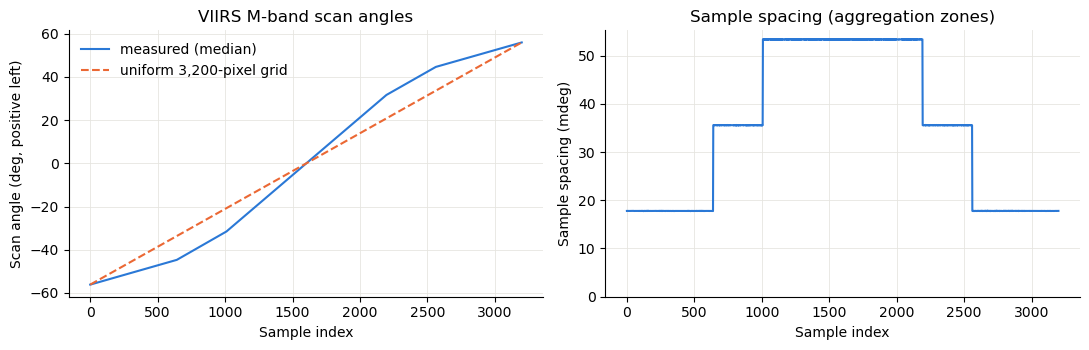

,first sample,last sample,samples aggregated,spacing (mdeg),scan angles (deg)
0,0,639,1,17.78,-56.13 to -44.77
1,639,1008,2,35.57,-44.77 to -31.64
2,1008,2191,3,53.35,-31.64 to 31.47
3,2191,2560,2,35.57,31.47 to 44.60
4,2560,3199,1,17.79,44.60 to 55.96


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(np.arange(N_SAMPLES), measured_angle, color=BLUE, label="measured (median)")
axes[0].plot(np.arange(N_SAMPLES), np.linspace(measured_angle[0], measured_angle[-1], N_SAMPLES), color=ORANGE, ls="--", label="uniform 3,200-pixel grid")
axes[0].set(xlabel="Sample index", ylabel="Scan angle (deg, positive left)", title="VIIRS M-band scan angles")
axes[1].plot(np.arange(N_SAMPLES - 1) + 0.5, spacing * 1e3, color=BLUE)
axes[1].set(xlabel="Sample index", ylabel="Sample spacing (mdeg)", title="Sample spacing (aggregation zones)", ylim=(0, None))
axes[0].legend(frameon=False)
fig.tight_layout()
plt.show()
pd.DataFrame(
    [
        {"first sample": a, "last sample": b, "samples aggregated": aggregation[a], "spacing (mdeg)": 1e3 * np.median(spacing[a:b]), "scan angles (deg)": f"{measured_angle[a]:.2f} to {measured_angle[b]:.2f}"}
        for a, b in zip(zones[:-1], zones[1:])
    ]
).round(2)

The scan angles are stable from granule to granule (a standard deviation of about 0.002 deg). The first sample is on the right of the direction of motion. The outermost sample centers lie 56.13 deg to the right and 55.96 deg to the left of nadir, a field of regard of 112.09 deg: about 0.47 deg narrower than the nominal 112.56 deg (which corresponds to the extent of the Earth view rather than to the outermost sample centers). At the swath edges, 0.24 deg corresponds to about 23 km on the ground.

Within the swath, on-board aggregation of 1, 2, or 3 detector samples per pixel produces five zones of constant angular spacing, the widest at nadir. A `PointedInstrument` divides its view into pixels of equal angular size, which differs from the VIIRS M-band pixel positions by up to 11 deg, so it cannot represent individual VIIRS pixels; the view as a whole, and hence the swath, is unaffected.

### Detector Array

The along-track view angles of detectors 0 and 15 (the first and last of the array) are compared at every subsampled sample of every scan of the downloaded granules. Their difference spans 15 detector spacings; the full array (16 detectors) spans 16/15 of it.

In [6]:
px_ok = np.all(np.abs(viirs_pixels["lat"]) <= 90, axis=(2, 3)) & (np.arange(N_SCANS)[np.newaxis, :] < viirs["n_scans"][granules, np.newaxis])
pos_p = viirs["SCPosition"][granules].astype(float)[px_ok]
vel_p = inertial_velocity(pos_p, viirs["SCVelocity"][granules].astype(float)[px_ok])
px_xyz = ecef(viirs_pixels["lon"], viirs_pixels["lat"], viirs_pixels["height"])[px_ok]  # (scan, detector, column, 3)
along_t, cross_t = view_tangents(pos_p[:, np.newaxis, np.newaxis], vel_p[:, np.newaxis, np.newaxis], px_xyz)
scan_angle_p = np.degrees(np.arctan((cross_t[:, 1] + cross_t[:, 2]) / 2))  # center detectors
# angle between the lines of sight of detectors 0 and 15, scaled to the full array
los = normalize(px_xyz - pos_p[:, np.newaxis, np.newaxis])
array_angle = 16 / 15 * np.degrees(np.arccos(np.clip(np.sum(los[:, 0] * los[:, 3], axis=-1), -1, 1)))
nadir = np.abs(scan_angle_p) < 5
ground_speed = np.median(np.linalg.norm(np.diff(ecef(*TO_GEODETIC.transform(*scan_pos[:2000].T)[:2]), axis=0), axis=-1)) / scan_period
altitude = np.median(TO_GEODETIC.transform(*scan_pos[::100].T)[2])
tailored = np.degrees(2 * np.arctan(ground_speed * scan_period / 2 / altitude))
pd.Series(
    {
        "detector array, near nadir (deg)": np.median(array_angle[nadir]),
        "detector array, |scan angle| > 50 deg (deg)": np.median(array_angle[np.abs(scan_angle_p) > 50]),
        "detector spacing, near nadir (mdeg)": 1e3 * np.median(array_angle[nadir]) / 16,
        "ground track advance per scan (km)": ground_speed * scan_period / 1e3,
        "along-track field of view tailored to one scan (deg)": tailored,
    }
).round(4)

detector array, near nadir (deg)                         0.8166
detector array, |scan angle| > 50 deg (deg)              0.8166
detector spacing, near nadir (mdeg)                     51.0383
ground track advance per scan (km)                      11.8937
along-track field of view tailored to one scan (deg)     0.8141
dtype: float64

The detector array spans about 0.82 deg along track at every scan angle, matching the along-track field of view tailored to one scan period (the angle subtended at nadir by the 11.8 km the ground track advances in 1.79 s). This angular extent is constant across the scan, whereas TAT-C's rectangular view is a rectangle in the tangent plane at nadir: its along-track edges are offset from the cross-track axis by a constant `tan(along_track_field_of_view / 2)`, so its angular along-track extent shrinks as the cosine of the scan angle, to 0.46 deg at 56 deg (Test 3).

### Scan Plane Orientation

For every tenth downloaded scan, the plane through the center detectors' lines of sight is fit by a singular value decomposition, and its normal is compared with the horizontal direction of the Earth-fixed and inertial velocity.

In [7]:
i2 = np.arange(0, len(pos_p), 10)
center_los = normalize((px_xyz[i2, 1] + px_xyz[i2, 2]) / 2 - pos_p[i2, np.newaxis])
normal = np.array([np.linalg.svd(x)[2][-1] for x in center_los])
vel_e = viirs["SCVelocity"][granules].astype(float)[px_ok][i2]
normal *= np.sign(np.sum(normal * vel_e, axis=-1))[:, np.newaxis]
sub_lon, sub_lat, _ = TO_GEODETIC.transform(pos_p[i2, 0], pos_p[i2, 1], pos_p[i2, 2])
u2 = up(sub_lon, sub_lat)


def yaw(direction, reference):
    """Signed angle (deg) from the horizontal projection of a reference direction to that of a direction."""
    a = normalize(reference - np.sum(reference * u2, axis=-1, keepdims=True) * u2)
    b = normalize(direction - np.sum(direction * u2, axis=-1, keepdims=True) * u2)
    return np.degrees(np.arctan2(np.sum(np.cross(a, b) * u2, axis=-1), np.sum(a * b, axis=-1)))


pd.DataFrame(
    {
        "yaw vs. Earth-fixed velocity (deg)": summarize(yaw(normal, vel_e)),
        "yaw vs. inertial velocity (deg)": summarize(yaw(normal, vel_p[i2])),
        "line of sight out of plane (deg)": summarize(np.degrees(np.abs(np.arcsin(np.einsum("kjc,kc->kj", center_los, normal))))),
    }
).T.round(3)

,n,median,p95 |x|,max |x|
yaw vs. Earth-fixed velocity (deg),488.0,-0.282,4.026,4.075
yaw vs. inertial velocity (deg),488.0,-0.122,0.123,0.123
line of sight out of plane (deg),195688.0,0.008,0.015,0.020


Like ATMS, VIIRS scans perpendicular to the inertial velocity (to within a constant 0.12 deg, reflecting the 0.56 s duration of the scan, which this analysis does not resolve), not to the Earth-fixed velocity (up to 4 deg). The inertial velocity frame is used for the `PointedInstrument` below.

## Test 3: Scan Footprint

The ground footprint of a VIIRS scan is a strip whose along-track length is the distance between detectors 0 and 15, scaled by 16/15 to span the full array. Consecutive scans advance by the distance between the scans' centers (the midpoint of detectors 7 and 8) at the same sample, and overlap where the length exceeds the advance.

TAT-C's footprint for a `PointedInstrument` with the nominal field of regard as its cross-track field of view, the along-track field of view tailored to one scan (Test 2), and the inertial velocity frame, is evaluated at the middle times of the same scans. Its along-track length at each scan angle is the distance between the two points of its rectangular boundary at that cross-track position, computed with `compute_projected_ray_position` (which `PointedInstrument.compute_footprint` uses for the footprint boundary). For reference, a view with a constant *angular* along-track extent is also evaluated: the along-track edges of a narrow view rolled to each scan angle, which TAT-C rotates rigidly.

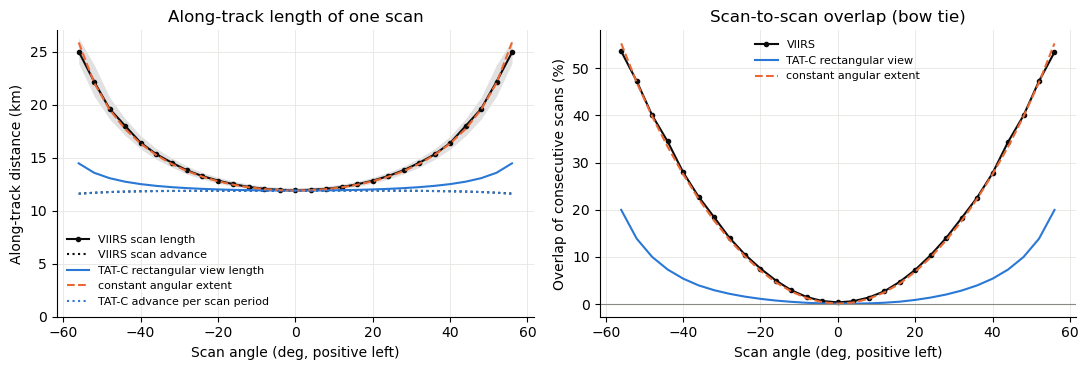

,VIIRS length (km),VIIRS advance (km),TAT-C length (km),constant angular extent (km),TAT-C advance (km)
nadir,11.93,11.89,11.89,11.89,11.88
left edge,24.99,11.61,14.46,25.86,11.57
right edge,24.92,11.61,14.46,25.86,11.58


In [8]:
viirs_view = PointedInstrument(
    name="VIIRS",
    field_of_regard=2 * EDGE,
    cross_track_field_of_view=2 * EDGE,
    along_track_field_of_view=tailored,
    is_rectangular=True,
    velocity_frame=VelocityFrame.INERTIAL,
)
# observed length and advance (km)
length = 16 / 15 * np.linalg.norm(px_xyz[:, 0] - px_xyz[:, 3], axis=-1) / 1e3
scan_center = (px_xyz[:, 1] + px_xyz[:, 2]) / 2
scan_index = np.flatnonzero(px_ok)  # granule * N_SCANS + scan
consecutive = np.nonzero((np.diff(scan_index) == 1) & (np.diff(scan_index // N_SCANS) == 0))[0]  # scan pairs within a granule
advance = np.linalg.norm(scan_center[consecutive + 1] - scan_center[consecutive], axis=-1) / 1e3

# TAT-C lengths and advances at a sample of scans and scan angles
i3 = np.arange(0, len(pos_p), 25)
scan_times3 = iet_to_utc(viirs["MidTime"][granules][px_ok][i3])
angles3 = np.arange(-56, 57, 4.0)
track3 = orbit.get_orbit_track(list(scan_times3))
track3_next = orbit.get_orbit_track([t + timedelta(seconds=scan_period) for t in scan_times3])
tatc_length, angular_length, tatc_advance = (np.zeros((len(i3), len(angles3))) for _ in range(3))


def distance(a, b):
    return GEOD.inv(a.longitude.degrees, a.latitude.degrees, b.longitude.degrees, b.latitude.degrees)[2] / 1e3


half = viirs_view.along_track_field_of_view / 2
tan_half = np.tan(np.radians(half))
for k, angle in enumerate(angles3):
    # rectangular boundary points at the cross-track position of the scan angle (clock angles from the left cross-track axis)
    clock = np.degrees(np.arctan2(tan_half, np.tan(np.radians(angle))))
    edge = lambda c: compute_projected_ray_position(
        track3, viirs_view.cross_track_field_of_view, viirs_view.along_track_field_of_view, 0, 0, True, c,
        velocity_frame=VelocityFrame.INERTIAL,
    )
    tatc_length[:, k] = distance(edge(clock), edge(360 - clock))
    # along-track edges of a narrow view rolled to the scan angle
    ray = lambda track, pitch: compute_projected_ray_position(track, 0, 0, angle, pitch, velocity_frame=VelocityFrame.INERTIAL)
    angular_length[:, k] = distance(ray(track3, half), ray(track3, -half))
    tatc_advance[:, k] = distance(ray(track3, 0), ray(track3_next, 0))

edges3 = np.arange(-58, 59, 4.0)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
q_len = binned(scan_angle_p.ravel(), length.ravel(), edges3)
q_adv = binned(scan_angle_p[consecutive].ravel(), advance.ravel(), edges3)
mid3 = (edges3[:-1] + edges3[1:]) / 2
axes[0].fill_between(mid3, q_len[:, 0], q_len[:, 2], color=INK, alpha=0.12, lw=0)
axes[0].plot(mid3, q_len[:, 1], color=INK, marker="o", ms=3, label="VIIRS scan length")
axes[0].plot(mid3, q_adv[:, 1], color=INK, ls=":", label="VIIRS scan advance")
axes[0].plot(angles3, np.median(tatc_length, axis=0), color=BLUE, label="TAT-C rectangular view length")
axes[0].plot(angles3, np.median(angular_length, axis=0), color=ORANGE, ls="--", label="constant angular extent")
axes[0].plot(angles3, np.median(tatc_advance, axis=0), color=BLUE, ls=":", label="TAT-C advance per scan period")
axes[0].set(xlabel="Scan angle (deg, positive left)", ylabel="Along-track distance (km)", title="Along-track length of one scan", ylim=(0, None))
axes[0].legend(frameon=False, fontsize=8)
axes[1].plot(mid3, 100 * (1 - q_adv[:, 1] / q_len[:, 1]), color=INK, marker="o", ms=3, label="VIIRS")
axes[1].plot(angles3, 100 * (1 - np.median(tatc_advance, axis=0) / np.median(tatc_length, axis=0)), color=BLUE, label="TAT-C rectangular view")
axes[1].plot(angles3, 100 * (1 - np.median(tatc_advance, axis=0) / np.median(angular_length, axis=0)), color=ORANGE, ls="--", label="constant angular extent")
axes[1].axhline(0, color=GRAY, lw=0.8)
axes[1].set(xlabel="Scan angle (deg, positive left)", ylabel="Overlap of consecutive scans (%)", title="Scan-to-scan overlap (bow tie)")
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()
pd.DataFrame(
    {
        "VIIRS length (km)": q_len[[len(mid3) // 2, 0, -1], 1],
        "VIIRS advance (km)": q_adv[[len(mid3) // 2, 0, -1], 1],
        "TAT-C length (km)": np.median(tatc_length, axis=0)[[len(angles3) // 2, 0, -1]],
        "constant angular extent (km)": np.median(angular_length, axis=0)[[len(angles3) // 2, 0, -1]],
        "TAT-C advance (km)": np.median(tatc_advance, axis=0)[[len(angles3) // 2, 0, -1]],
    },
    index=["nadir", "left edge", "right edge"],
).round(2)

At nadir, a VIIRS scan is 11.9 km long and consecutive scans advance by the same distance, so scans neither overlap nor leave gaps, and TAT-C's tailored view matches. Toward the swath edges, the scan's angular extent is constant while the distance to the ground grows, so the scan's along-track length roughly doubles, to 25 km, while the advance shrinks slightly with Earth's curvature: consecutive scans overlap by about 54% at the edges, the bow tie effect for which VIIRS discards some overlapping pixels on board. A view with constant angular along-track extent reproduces this to within about 1 km. TAT-C's rectangular view grows only to 14.5 km, underestimating the length of a scan (and of edge pixels) by about 40% at the swath edges. Because TAT-C's footprints are never shorter than the advance, consecutive footprints still tile the swath without gaps, so coverage is unaffected.

## Test 4: Swath Width

The observed swath width is the distance along the surface from the first to the last sample of the center detectors, through the subsampled intermediate samples, for every scan of the downloaded granules. As in the ATMS notebook, TAT-C's swath width is computed from the field of regard at the geodetic altitude, and from the minimum elevation angle used by `collect_observations`.

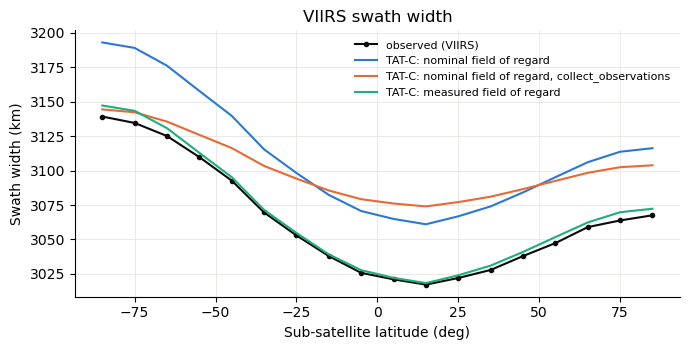

,n,median,p95 |x|,max |x|
nominal field of regard,4872.0,46.9,54.6,64.0
"nominal field of regard, collect_observations",4872.0,41.9,57.1,66.4
measured field of regard,4872.0,2.9,10.2,18.3


In [9]:
observed_width = np.sum(np.linalg.norm(np.diff(scan_center, axis=1), axis=-1), axis=1) / 1e3
sub_lon4, sub_lat4, sub_alt4 = TO_GEODETIC.transform(pos_p[:, 0], pos_p[:, 1], pos_p[:, 2])
measured_for = np.abs(measured_angle[0] - measured_angle[-1])
apogee_altitude = compute_apoapsis_radius(noaa20.orbit.get_semimajor_axis(), noaa20.orbit.get_eccentricity()) - EARTH_MEAN_RADIUS
min_elevation_angle = compute_min_elevation_angle(apogee_altitude, 2 * EDGE)
swath_width = np.vectorize(field_of_regard_to_swath_width)
widths = {
    "nominal field of regard": swath_width(sub_alt4, 2 * EDGE) / 1e3,
    "nominal field of regard, collect_observations": swath_width(sub_alt4, np.vectorize(compute_field_of_regard)(sub_alt4, min_elevation_angle)) / 1e3,
    "measured field of regard": swath_width(sub_alt4, measured_for) / 1e3,
}
edges4 = np.arange(-90, 91, 10)
mid4 = (edges4[:-1] + edges4[1:]) / 2
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(mid4, binned(sub_lat4, observed_width, edges4)[:, 1], color=INK, marker="o", ms=3, label="observed (VIIRS)")
for (name, width), color in zip(widths.items(), [BLUE, ORANGE, AQUA]):
    ax.plot(mid4, binned(sub_lat4, width, edges4)[:, 1], color=color, label=f"TAT-C: {name}")
ax.set(xlabel="Sub-satellite latitude (deg)", ylabel="Swath width (km)", title="VIIRS swath width")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()
pd.DataFrame({name: summarize(width - observed_width) for name, width in widths.items()}).T.round(1)

The VIIRS swath is about 3,020 km wide near the equator and 3,140 km at high southern latitudes, following NOAA-20's geodetic altitude as for ATMS. TAT-C's nominal field of regard makes it about 47 km too wide (median); the measured field of regard (Test 2) agrees to within 3 km (median). The equivalent swath in `collect_observations` is similarly too wide near the equator.

## Test 5: Daily Observations

`collect_observations` is evaluated for 2,598 points on a Fibonacci lattice with a typical spacing of 500 km, as in the ATMS notebook.

**Observed.** A point is observed by a granule if it lies inside the granule's G-ring (a polygon of 8 vertices on the outermost pixel centers, connected by great circles). Granules observing a point less than 20 minutes apart belong to the same pass. The observation time is interpolated between the granule's first and last scans from the point's distances to the great circles through the G-ring's first and last scan lines, and the elevation angle is computed from the reported spacecraft position at that time.

**Predicted.** A nadir `Instrument` and the rectangular `PointedInstrument` of Test 3 (inertial frame, along-track field of view tailored to one scan), each with the nominal field of regard, and the same `PointedInstrument` with the measured field of regard (Test 2). Predicted and observed passes of the same point are matched if their times differ by less than 10 minutes.

In [10]:
points5 = generate_points_fibonacci_lattice(500e3)
point_xyz = up(points5.geometry.x.to_numpy(), points5.geometry.y.to_numpy())
ring = up(viirs["gring_lon"], viirs["gring_lat"])  # (granule, vertex, 3)
last_scan = viirs["n_scans"] - 1
gran_first = iet_to_utc(viirs["MidTime"][:, 0])
gran_last = iet_to_utc(viirs["MidTime"][np.arange(len(ring)), last_scan])
first_sub = normalize(viirs["SCPosition"][:, 0].astype(float))
observed_rows = []
for g in range(len(ring)):
    vertices = ring[g]
    edges = np.cross(vertices, np.roll(vertices, -1, axis=0))
    # inside every edge's great circle, on the same side as the polygon's centroid
    orientation = np.sign(edges @ vertices.mean(axis=0))
    inside = np.all((point_xyz @ edges.T) * orientation >= 0, axis=1)
    if not inside.any():
        continue
    # scan lines through G-ring vertices 2-4 and 6-0; the first is the one nearest the first scan's nadir
    lines = [normalize(np.cross(vertices[2], vertices[4])), normalize(np.cross(vertices[6], vertices[0]))]
    if np.abs(lines[1] @ first_sub[g]) < np.abs(lines[0] @ first_sub[g]):
        lines = lines[::-1]
    d_first, d_last = (np.abs(point_xyz[inside] @ line) for line in lines)
    fraction = d_first / (d_first + d_last)
    times = gran_first[g] + (gran_last[g] - gran_first[g]) * fraction
    for p, t in zip(np.flatnonzero(inside), times):
        observed_rows.append({"point_id": p, "granule": g, "time": t})
observed5 = pd.DataFrame(observed_rows).astype({"point_id": "int64"}).sort_values(["point_id", "time"])
# one observation per pass (granules less than 20 minutes apart)
new_pass = observed5.groupby("point_id").time.diff().fillna(pd.Timedelta(days=1)) > pd.Timedelta(minutes=20)
observed5 = observed5[new_pass.to_numpy()].reset_index(drop=True)
# elevation angle from the reported spacecraft position, interpolated linearly in time between scans
scan_seconds = (scan_mid - scan_mid[0]).total_seconds().to_numpy()
obs_seconds = (observed5.time - scan_mid[0]).dt.total_seconds().to_numpy()
k = np.clip(np.searchsorted(scan_seconds, obs_seconds) - 1, 0, len(scan_seconds) - 2)
position = scan_pos[k] + scan_vel[k] * (obs_seconds - scan_seconds[k])[:, np.newaxis]
target = ecef(points5.geometry.x.to_numpy()[observed5.point_id], points5.geometry.y.to_numpy()[observed5.point_id])
observed5["elevation"] = np.degrees(np.arcsin(np.sum(normalize(position - target) * point_xyz[observed5.point_id], axis=-1)))

start5, end5 = scan_mid[0].to_pydatetime(), scan_mid[-1].to_pydatetime()
instruments5 = {
    "nadir Instrument": Instrument(name="VIIRS", field_of_regard=2 * EDGE),
    "PointedInstrument, inertial": viirs_view,
    "PointedInstrument, inertial, measured field of regard": viirs_view.model_copy(
        update={"field_of_regard": measured_for, "cross_track_field_of_view": measured_for}
    ),
}


def match(predicted):
    """Match predicted and observed passes of each point by time."""
    return pd.merge_asof(
        observed5.sort_values("time"),
        predicted[["point_id", "epoch", "sat_alt"]].sort_values("epoch"),
        left_on="time", right_on="epoch", by="point_id",
        direction="nearest", tolerance=pd.Timedelta(minutes=10),
    )


predicted5, matched5, rows5 = {}, {}, {}
for name, instrument in instruments5.items():
    satellite = noaa20.model_copy(update={"instruments": [instrument]})
    predicted5[name] = pd.concat(
        [collect_observations(Point(id=p, latitude=g.y, longitude=g.x), satellite, start5, end5) for p, g in enumerate(points5.geometry)]
    ).reset_index(drop=True)
    predicted5[name]["point_id"] = predicted5[name].point_id.astype("int64")
    matched5[name] = match(predicted5[name])
    hit = matched5[name].epoch.notna()
    dt = (matched5[name].epoch - matched5[name].time).dt.total_seconds()[hit]
    rows5[name] = {
        "observed": len(observed5),
        "predicted": len(predicted5[name]),
        "matched": int(hit.sum()),
        "observed only": int((~hit).sum()),
        "predicted only": len(predicted5[name]) - int(hit.sum()),
        "time, median (s)": np.median(dt),
        "time, p95 |x| (s)": np.percentile(np.abs(dt), 95),
        "elevation, median (deg)": np.median((matched5[name].sat_alt - matched5[name].elevation)[hit]),
        "elevation, p95 |x| (deg)": np.percentile(np.abs(matched5[name].sat_alt - matched5[name].elevation)[hit], 95),
    }
pd.DataFrame(rows5).T.round(2)

,observed,predicted,matched,observed only,predicted only,"time, median (s)","time, p95 |x| (s)","elevation, median (deg)","elevation, p95 |x| (deg)"
nadir Instrument,8715.0,8987.0,8715.0,0.0,272.0,0.26,13.61,0.03,0.10
"PointedInstrument, inertial",8715.0,8941.0,8715.0,0.0,226.0,0.22,1.99,0.00,0.05
"PointedInstrument, inertial, measured field of regard",8715.0,8837.0,8700.0,15.0,137.0,0.23,1.99,0.00,0.05


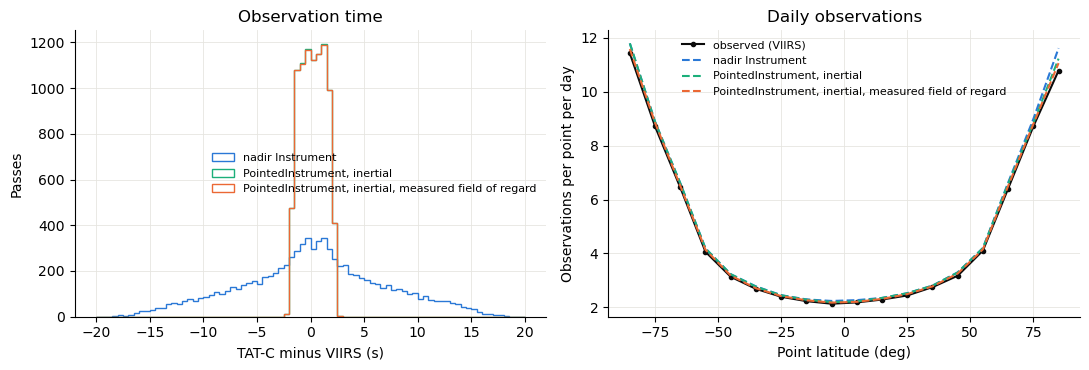

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for (name, matched), color in zip(matched5.items(), [BLUE, AQUA, ORANGE]):
    hit = matched.epoch.notna()
    dt = (matched.epoch - matched.time).dt.total_seconds()
    axes[0].hist(dt[hit], bins=np.arange(-20, 20.5, 0.5), color=color, histtype="step", lw=1.5, label=name)
axes[0].set(xlabel="TAT-C minus VIIRS (s)", ylabel="Passes", title="Observation time")
axes[0].legend(frameon=False, fontsize=8)
lat_edges = np.arange(-90, 91, 10)
point_lat = points5.geometry.y.to_numpy()
n_points = np.histogram(point_lat, lat_edges)[0]
axes[1].plot((lat_edges[:-1] + lat_edges[1:]) / 2, np.histogram(point_lat[observed5.point_id], lat_edges)[0] / n_points, color=INK, marker="o", ms=3, label="observed (VIIRS)")
for (name, predicted), color in zip(predicted5.items(), [BLUE, AQUA, ORANGE]):
    axes[1].plot((lat_edges[:-1] + lat_edges[1:]) / 2, np.histogram(point_lat[predicted.point_id], lat_edges)[0] / n_points, color=color, ls="--", label=name)
axes[1].set(xlabel="Point latitude (deg)", ylabel="Observations per point per day", title="Daily observations")
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

Every observed pass is predicted by the nadir `Instrument` and the `PointedInstrument` with the nominal field of regard, from about 2 observations per day at the equator to about 11 near the poles. About 2 to 3% of predicted passes were not observed: with the nominal field of regard, TAT-C's swath is about 47 km too wide (Test 4), and the excess shows near the poles, where many points lie near swath edges. The measured field of regard reduces these to 1.6% while matching 99.8% of observed passes; the remainder are at the swath edges, where the G-ring (three vertices per 570 km granule edge) only approximates the outermost pixels.

As for ATMS, the nadir `Instrument`'s epochs (the time of closest approach) differ from the time VIIRS scans a point by up to about 13 s (95th percentile), because the scan is rotated from the perpendicular to the ground track, while an inertial-frame `PointedInstrument` agrees to within 2 s (95th percentile), the precision of the observation times interpolated from the G-ring. Elevation angles agree to a few hundredths of a degree.

## Summary

| Test | Result |
| --- | --- |
| 1. Orbit (operational TLE vs. reported position) | 1.1 km along track (95th percentile), 0.4 km or better radially and cross-track |
| 2. Scan geometry | outermost samples 56.13 and 55.96 deg from nadir (field of regard 112.09 deg vs. nominal 112.56 deg); detector array 0.817 deg along track at all scan angles, matching the 0.814 deg tailored to one scan period; scan perpendicular to the *inertial* velocity (within 0.12 deg) |
| 3. Scan footprint | rectangular view tailored to one scan matches the 11.9 km scan length at nadir, but reaches only 14.5 km at the edges vs. 25 km observed (constant angular extent: 25.9 km); consecutive footprints tile the swath |
| 4. Swath width | 47 km too wide with the nominal field of regard, 3 km with the measured one (median) |
| 5. Daily observations (`collect_observations`) | all observed passes predicted with the nominal field of regard (2 to 3% extra), 99.8% with the measured one (1.6% extra); epochs within 2 s (95th percentile) for an inertial-frame `PointedInstrument`, vs. 13 s for a nadir `Instrument` |

**Scan orientation and timing.** VIIRS confirms the ATMS findings: NOAA-20's instruments scan perpendicular to the inertial velocity, so `velocity_frame=VelocityFrame.INERTIAL` is the appropriate setting for a `PointedInstrument` representing either instrument, and it makes the observation epochs of `collect_observations` match the actual scan times. VIIRS's Earth view lasts only 0.56 s, so the along-track error from observing a whole view at one instant is under 2 km at the swath edges.

**Along-track field of view as integration time.** VIIRS's 16-detector array is designed to cover the ground traveled in one scan period, and the along-track field of view tailored to one scan period (0.814 deg) matches its angular extent (0.817 deg). At nadir, TAT-C's footprint therefore matches a VIIRS scan. Toward the swath edges, however, TAT-C's rectangular view is a rectangle in the tangent plane at nadir, like the focal plane of a framing camera or pushbroom imager, so its angular along-track extent shrinks as the cosine of the scan angle. A scanning imager such as VIIRS keeps a constant angular extent, so its scans grow to about twice their nadir length at the edges and overlap (the bow tie effect). TAT-C's footprints still tile the swath, so coverage and revisit are unaffected, but footprint and pixel sizes near the edges of a scanning imager's swath are underestimated by up to about 40%.

**Instrument parameters.** The nominal VIIRS scan half-angle of 56.28 deg describes the extent of the Earth view; the outermost M-band pixel centers lie about 0.24 deg closer to nadir. For coverage analysis, a field of regard of about 112.1 deg reproduces the swath to within a few kilometers. Within the swath, on-board pixel aggregation makes the VIIRS M-band pixel spacing nonuniform in angle, which a `PointedInstrument`'s equal-angle pixel grid cannot represent.